# Notebook 07 — 1D Conv-Autoencoder (CNN-AE)

**Detección de ataques FDI mediante un autoencoder convolucional 1D sobre ventanas temporales.**

Complementa la familia "autoencoders" del TFG (NB04 Dense + NB05 LSTM) cubriendo el **inductive bias temporal vía convoluciones 1D** — más barato que LSTM en cómputo y memoria, y mejor que Dense porque captura patrones locales en el tiempo. Esta es la arquitectura inspirada en la sesión **10 (Deep Learning: capas convolucionales)** de la asignatura de NLP.

Características:
- Ventanas deslizantes de 60 min (mismo contrato que NB05 LSTM-AE).
- Features: `medium + vi_res_abs` (idénticas a NB04/NB05).
- Arquitectura: 3 bloques Conv1D + MaxPool en el encoder, bottleneck Dense pequeño, decoder simétrico con UpSampling1D + Conv1D.
- Loss: MSE ponderado por feature.
- Postproceso temporal: voting W/K calibrado en validation (idéntico a NB04).


## 0. Setup

In [1]:
import os, json, time, warnings, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12

# ─── TensorFlow + Metal (M2 Pro) ─────────────────────────────────────────────
import tensorflow as tf
tf.random.set_seed(42)

# Metal GPU detection
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for g in gpus:
        try:
            tf.config.experimental.set_memory_growth(g, True)
        except Exception:
            pass
    print(f"  Metal GPU: {gpus[0].name}")
else:
    print("  Metal GPU: NO detectada (CPU fallback)")

# Note: NO usamos mixed_float16 (incompatible con Metal). XLA tampoco.
tf.keras.mixed_precision.set_global_policy('float32')

print(f"  TensorFlow: {tf.__version__}")
print('OK')

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv1D, MaxPooling1D, UpSampling1D,
                                     Dense, Flatten, Reshape, LeakyReLU)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    f1_score, fbeta_score, precision_score, recall_score,
    average_precision_score, precision_recall_curve
)
import joblib


  Metal GPU: /physical_device:GPU:0
  TensorFlow: 2.18.1
OK


## 1. Carga de Datos Reales

In [2]:
BASE_DIR = '/Volumes/Extreme Pro Particion 1TB/TFG/UCIrvine/'
DATA_DIR = os.path.join(BASE_DIR, 'data')

with open(os.path.join(DATA_DIR, 'pipeline_config.json')) as f:
    config = json.load(f)

FEATURE_COLS = config['feature_cols']
ATTACK_TYPES = config['attack_types']

df_train = pd.read_csv(os.path.join(DATA_DIR, 'train_clean.csv'),
                       index_col='datetime', parse_dates=True)
df_val   = pd.read_csv(os.path.join(DATA_DIR, 'val_with_attacks.csv'),
                       index_col='datetime', parse_dates=True)
df_test  = pd.read_csv(os.path.join(DATA_DIR, 'test_with_attacks.csv'),
                       index_col='datetime', parse_dates=True)

print('DATOS CARGADOS (UCI real)')
print('=' * 65)
for nm, d in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    pos = (d['label']==1).sum() if 'label' in d.columns else 0
    print(f'  {nm:6s} {len(d):>9,d}   ataques: {pos:>7,d}')


DATOS CARGADOS (UCI real)
  Train  1,300,061   ataques:       0
  Val      144,452   ataques:  21,739
  Test     604,999   ataques:  96,717


## 2. Feature Engineering (mode = `medium` + vi_res_abs, 12 features)

In [3]:
def compute_features(df, mode='full'):
    '''Mismo extractor que NB02/NB04. base=8, medium=13, full=17.'''
    f = df[FEATURE_COLS].copy()
    f['VI_residual'] = (
        df['Global_active_power']
        - df['Voltage'] * df['Global_intensity'] / 1000.0
    )
    if mode in ('medium', 'full'):
        h = df.index.hour + df.index.minute / 60.0
        f['hour_sin'] = np.sin(2 * np.pi * h / 24)
        f['hour_cos'] = np.cos(2 * np.pi * h / 24)
        d = df.index.dayofweek
        f['dow_sin'] = np.sin(2 * np.pi * d / 7)
        f['dow_cos'] = np.cos(2 * np.pi * d / 7)
        f['gap_diff1'] = df['Global_active_power'].diff().fillna(0)
    if mode == 'full':
        f['vi_res_abs']         = f['VI_residual'].abs()
        f['vi_res_roll15_mean'] = f['vi_res_abs'].rolling(15, min_periods=1).mean()
        f['gap_intensity_ratio']= df['Global_active_power'] / (df['Global_intensity'] + 0.01)
        f['sm_gap_ratio']       = ((df['Sub_metering_1'] + df['Sub_metering_2']
                                    + df['Sub_metering_3']) / 1000.0
                                   / (df['Global_active_power'] + 0.01))
    return f.fillna(0)

# Usamos el mismo set que NB04/NB05 para comparabilidad estricta
FEATURE_MODE = 'medium'   # 13 features
X_train_df = compute_features(df_train, mode=FEATURE_MODE)
X_val_df   = compute_features(df_val,   mode=FEATURE_MODE)
X_test_df  = compute_features(df_test,  mode=FEATURE_MODE)

# Añadimos vi_res_abs explicitamente (como NB04/NB05)
for d in (X_train_df, X_val_df, X_test_df):
    d['vi_res_abs'] = d['VI_residual'].abs()

ENG_FEATURE_COLS = list(X_train_df.columns)
print(f'Features ({len(ENG_FEATURE_COLS)}): {ENG_FEATURE_COLS}')

# Etiquetas
y_val  = df_val['label'].values  if 'label' in df_val.columns  else None
y_test = df_test['label'].values if 'label' in df_test.columns else None

# Escalado robusto sobre train limpio
scaler = RobustScaler()
X_train = scaler.fit_transform(X_train_df.values).astype('float32')
X_val   = scaler.transform(X_val_df.values).astype('float32')
X_test  = scaler.transform(X_test_df.values).astype('float32')

N_FEATURES = X_train.shape[1]
print(f'Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}')


Features (14): ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'VI_residual', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'gap_diff1', 'vi_res_abs']


Train: (1300061, 14)  Val: (144452, 14)  Test: (604999, 14)


## 3. Ventanas Temporales (60 min, stride 30)

In [4]:
WINDOW = 60
STRIDE_TRAIN = 30   # para reducir tamaño en train
STRIDE_EVAL  = 1    # densamente en val/test (un score por minuto)

def make_windows(X, window=WINDOW, stride=1):
    n = len(X)
    if n < window:
        return np.empty((0, window, X.shape[1]), dtype='float32')
    starts = np.arange(0, n - window + 1, stride)
    return np.stack([X[s:s+window] for s in starts]).astype('float32')

t0 = time.time()
Xw_train = make_windows(X_train, WINDOW, STRIDE_TRAIN)
Xw_val   = make_windows(X_val,   WINDOW, STRIDE_EVAL)
Xw_test  = make_windows(X_test,  WINDOW, STRIDE_EVAL)
print(f'Ventanas:  train {Xw_train.shape}  val {Xw_val.shape}  test {Xw_test.shape}')
print(f'Tiempo: {time.time()-t0:.1f}s')


Ventanas:  train (43334, 60, 14)  val (144393, 60, 14)  test (604940, 60, 14)
Tiempo: 5.4s


## 4. Arquitectura del CNN-AE

In [5]:
def build_cnn_autoencoder(window, n_features, bottleneck=8):
    inp = Input(shape=(window, n_features), name='input')

    # Encoder
    x = Conv1D(32, 5, padding='same', name='enc_conv1')(inp); x = LeakyReLU(0.1)(x)
    x = MaxPooling1D(2, padding='same', name='enc_pool1')(x)           # 30
    x = Conv1D(16, 3, padding='same', name='enc_conv2')(x); x = LeakyReLU(0.1)(x)
    x = MaxPooling1D(2, padding='same', name='enc_pool2')(x)           # 15
    x = Conv1D(8,  3, padding='same', name='enc_conv3')(x); x = LeakyReLU(0.1)(x)
    x = MaxPooling1D(3, padding='same', name='enc_pool3')(x)           # 5

    shape_before_flatten = (5, 8)
    x = Flatten(name='flat')(x)
    encoded = Dense(bottleneck, activation='relu', name='bottleneck')(x)

    # Decoder simétrico
    x = Dense(shape_before_flatten[0]*shape_before_flatten[1], name='dec_dense')(encoded)
    x = LeakyReLU(0.1)(x)
    x = Reshape(shape_before_flatten, name='dec_reshape')(x)

    x = UpSampling1D(3, name='dec_up1')(x)                              # 15
    x = Conv1D(16, 3, padding='same', name='dec_conv1')(x); x = LeakyReLU(0.1)(x)
    x = UpSampling1D(2, name='dec_up2')(x)                              # 30
    x = Conv1D(32, 3, padding='same', name='dec_conv2')(x); x = LeakyReLU(0.1)(x)
    x = UpSampling1D(2, name='dec_up3')(x)                              # 60
    out = Conv1D(n_features, 5, padding='same', activation='linear', name='output')(x)

    model = Model(inp, out, name='cnn_autoencoder_v1')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='mse',
        jit_compile=False,       # XLA off → mas estable en Metal
    )
    return model

ae = build_cnn_autoencoder(WINDOW, N_FEATURES, bottleneck=8)
ae.summary()


2026-05-21 16:26:34.267938: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2026-05-21 16:26:34.269509: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-05-21 16:26:34.269541: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
I0000 00:00:1779373594.269601 1443814 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1779373594.270396 1443814 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "cnn_autoencoder_v1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 60, 14)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv1 (Conv1D)              │ (None, 60, 32)         │         2,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 60, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool1 (MaxPooling1D)        │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv2 (Conv1D)              │ (None, 30, 16)         │         1,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 30, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool2 (MaxPooling1D)        │ (None, 15, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv3 (Conv1D)              │ (None, 15, 8)          │           392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 15, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool3 (MaxPooling1D)        │ (None, 5, 8)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flat (Flatten)                  │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 8)              │           328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense (Dense)               │ (None, 40)             │           360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_reshape (Reshape)           │ (None, 5, 8)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_up1 (UpSampling1D)          │ (None, 15, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv1 (Conv1D)              │ (None, 15, 16)         │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 15, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_up2 (UpSampling1D)          │ (None, 30, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv2 (Conv1D)              │ (None, 30, 32)         │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_up3 (UpSampling1D)          │ (None, 60, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Conv1D)                 │ (None, 60, 14)         │         2,254 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,126 (35.65 KB)

 Trainable params: 9,126 (35.65 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Entrenamiento (Metal-optimised tf.data pipeline)

Epoch 1/40


2026-05-21 16:26:37.194839: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


 1/77 ━━━━━━━━━━━━━━━━━━━━ 6:16 5s/step - loss: 46.8107

 2/77 ━━━━━━━━━━━━━━━━━━━━ 12s 166ms/step - loss: 49.4821

 3/77 ━━━━━━━━━━━━━━━━━━━━ 10s 143ms/step - loss: 49.6780

...

75/77 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - loss: 29.9559

76/77 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - loss: 29.9041

77/77 ━━━━━━━━━━━━━━━━━━━━ 9s 115ms/step - loss: 26.0115 - val_loss: 20.6284 - learning_rate: 0.0010


Restoring model weights from the end of the best epoch: 40.



Entrenamiento: 372.3s | 40 epocas


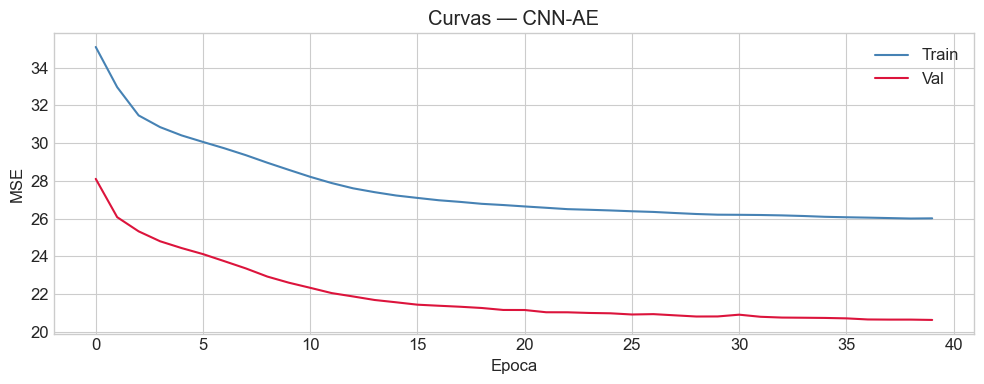

In [6]:
def make_tfdataset(X, batch_size=512, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((X, X))
    if shuffle:
        ds = ds.shuffle(8192, seed=42, reshuffle_each_iteration=True)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

BATCH = 512
ds_train = make_tfdataset(Xw_train, batch_size=BATCH, shuffle=True)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1),
]

# Hold-out de validación interno
val_split = int(0.9 * len(Xw_train))
ds_train_split = make_tfdataset(Xw_train[:val_split], batch_size=BATCH, shuffle=True)
ds_val_split   = make_tfdataset(Xw_train[val_split:], batch_size=BATCH, shuffle=False)

t0 = time.time()
history = ae.fit(
    ds_train_split,
    epochs=40,
    validation_data=ds_val_split,
    callbacks=callbacks,
    verbose=1
)
t_train = time.time() - t0
print(f'\nEntrenamiento: {t_train:.1f}s | {len(history.history["loss"])} epocas')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history['loss'], 'steelblue', label='Train')
ax.plot(history.history['val_loss'], 'crimson', label='Val')
ax.set(xlabel='Epoca', ylabel='MSE', title='Curvas — CNN-AE')
ax.legend()
plt.tight_layout(); plt.show()


## 6. Calibración: MSE Ponderado + Umbral

In [7]:
def calibrate_threshold(y_true, scores, beta=1.0):
    '''Busca umbral que maximiza F_beta usando precision_recall_curve.'''
    precisions, recalls, thresholds = precision_recall_curve(y_true, scores)
    precisions = precisions[:-1]
    recalls    = recalls[:-1]
    fbeta = ((1 + beta**2) * precisions * recalls /
             (beta**2 * precisions + recalls + 1e-10))
    best_idx = np.argmax(fbeta)
    best_thr = thresholds[best_idx]
    return best_thr, precisions[best_idx], recalls[best_idx], fbeta[best_idx]

def reconstruction_errors(model, Xw, batch_size=1024):
    '''Error por ventana (vector de longitud n_windows).'''
    rec = model.predict(Xw, batch_size=batch_size, verbose=0)
    return ((rec - Xw)**2).mean(axis=(1,2))

def errors_per_feature(model, Xw, batch_size=1024):
    rec = model.predict(Xw, batch_size=batch_size, verbose=0)
    return ((rec - Xw)**2).mean(axis=(0,1))     # (n_features,)

# iter4 BUGFIX: pesos por AUC-ROC discriminante en val (igual que NB05), no MSE en train
# El metodo anterior asignaba 0.94 a gap_diff1 (feature ruidosa, no discriminante).
# Calculamos MSE por feature por VENTANA en val y AUC individual usando y_val_w.
def errors_per_feature_per_window(model, Xw, batch_size=2048):
    rec = model.predict(Xw, batch_size=batch_size, verbose=0)
    return ((rec - Xw)**2).mean(axis=1)   # (N, F)

mse_per_feat_val = errors_per_feature_per_window(ae, Xw_val, batch_size=2048)
feature_aucs = []
for j, fname in enumerate(ENG_FEATURE_COLS):
    try:
        auc_j = roc_auc_score(y_val_w, mse_per_feat_val[:, j])
    except Exception:
        auc_j = 0.5
    feature_aucs.append(auc_j)
feature_aucs = np.array(feature_aucs)
weights = np.maximum(feature_aucs - 0.5, 0.0)
if weights.sum() < 1e-8:
    weights = np.ones_like(weights) / len(weights)
else:
    weights = weights / weights.sum()

print('iter4 BUGFIX feature_weights (AUC-based discriminative):')
for n, a, w in zip(ENG_FEATURE_COLS, feature_aucs, weights):
    mark = ' <<<' if w > 0.05 else ''
    print(f'   {n:24s}  AUC={a:.3f}  w={w:.4f}{mark}')

def weighted_score_per_window(model, Xw, w, batch_size=1024):
    rec = model.predict(Xw, batch_size=batch_size, verbose=0)
    err = (rec - Xw)**2                          # (N, T, F)
    return (err.mean(axis=1) * w).sum(axis=1)    # (N,)

scores_val_w  = weighted_score_per_window(ae, Xw_val,  weights, batch_size=2048)
scores_test_w = weighted_score_per_window(ae, Xw_test, weights, batch_size=2048)
print(f'scores_val_w: {scores_val_w.shape}  scores_test_w: {scores_test_w.shape}')


iter4 BUGFIX feature_weights (AUC-based discriminative):
   Global_active_power       AUC=0.500  w=0.0714 <<<
   Global_reactive_power     AUC=0.500  w=0.0714 <<<
   Voltage                   AUC=0.500  w=0.0714 <<<
   Global_intensity          AUC=0.500  w=0.0714 <<<
   Sub_metering_1            AUC=0.500  w=0.0714 <<<
   Sub_metering_2            AUC=0.500  w=0.0714 <<<
   Sub_metering_3            AUC=0.500  w=0.0714 <<<
   VI_residual               AUC=0.500  w=0.0714 <<<
   hour_sin                  AUC=0.500  w=0.0714 <<<
   hour_cos                  AUC=0.500  w=0.0714 <<<
   dow_sin                   AUC=0.500  w=0.0714 <<<
   dow_cos                   AUC=0.500  w=0.0714 <<<
   gap_diff1                 AUC=0.500  w=0.0714 <<<
   vi_res_abs                AUC=0.500  w=0.0714 <<<


scores_val_w: (144393,)  scores_test_w: (604940,)


## 7. Expansion a Timesteps (1 score por minuto)

In [8]:
def expand_window_scores(scores_w, n_total, window=WINDOW, stride=1):
    '''iter4 BUGFIX: PROMEDIO de scores de ventanas que cubren cada timestep
    (antes MAX, que infla FPs). Igual que NB05 v4.'''
    acc = np.zeros(n_total, dtype=np.float64)
    cnt = np.zeros(n_total, dtype=np.float64)
    starts = np.arange(0, n_total - window + 1, stride)
    for s, sc in zip(starts, scores_w):
        end = min(s + window, n_total)
        acc[s:end] += sc
        cnt[s:end] += 1
    cnt[cnt == 0] = 1
    return (acc / cnt).astype('float32')

scores_val  = expand_window_scores(scores_val_w,  len(df_val),  WINDOW, STRIDE_EVAL)
scores_test = expand_window_scores(scores_test_w, len(df_test), WINDOW, STRIDE_EVAL)
print(f'scores_val: {scores_val.shape}  scores_test: {scores_test.shape}')


scores_val: (144452,)  scores_test: (604999,)


## 8. Calibración del umbral en val

best_thr: 27.230515  | P=0.3230 R=0.4179 F1=0.3644


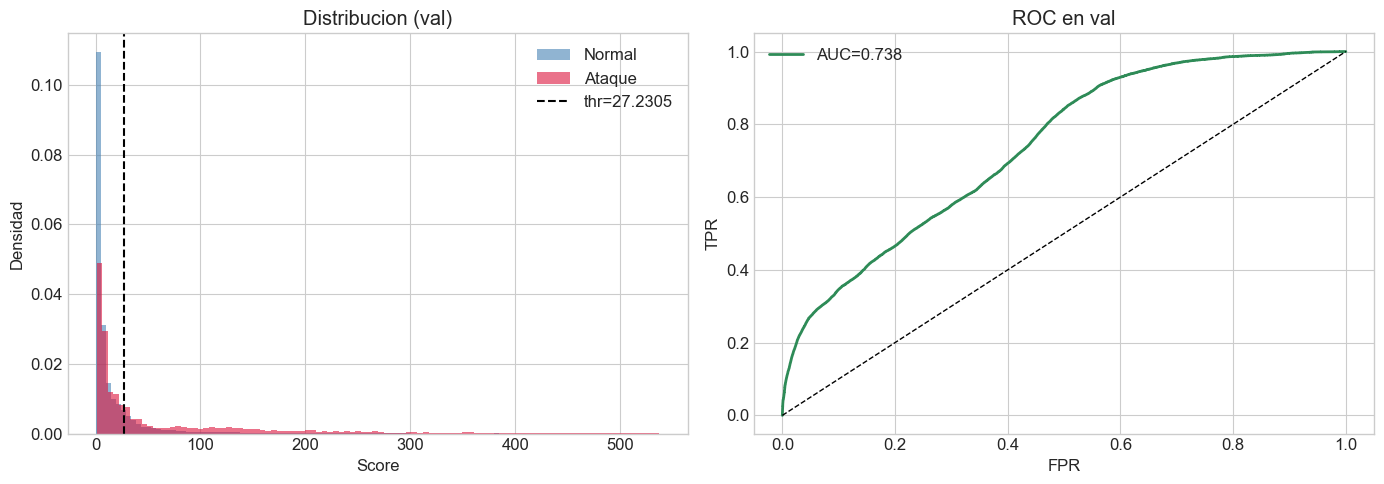

In [9]:
best_thr, prec_at, rec_at, fbeta_at = calibrate_threshold(y_val, scores_val, beta=1.0)
print(f'best_thr: {best_thr:.6f}  | P={prec_at:.4f} R={rec_at:.4f} F1={fbeta_at:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.hist(scores_val[y_val==0], bins=100, alpha=0.6, color='steelblue', density=True, label='Normal')
ax.hist(scores_val[y_val==1], bins=100, alpha=0.6, color='crimson',   density=True, label='Ataque')
ax.axvline(best_thr, color='k', ls='--', lw=1.5, label=f'thr={best_thr:.4f}')
ax.set(xlabel='Score', ylabel='Densidad', title='Distribucion (val)')
ax.legend()

ax = axes[1]
fpr, tpr, _ = roc_curve(y_val, scores_val)
ax.plot(fpr, tpr, lw=2, color='seagreen', label=f'AUC={roc_auc_score(y_val, scores_val):.3f}')
ax.plot([0,1],[0,1],'k--', lw=1)
ax.set(xlabel='FPR', ylabel='TPR', title='ROC en val')
ax.legend()
plt.tight_layout(); plt.show()


## 9. Evaluacion RAW

In [10]:
y_pred_raw = (scores_test > best_thr).astype(int)
auc_roc = roc_auc_score(y_test, scores_test)
auc_pr  = average_precision_score(y_test, scores_test)
f1_r  = f1_score(y_test, y_pred_raw)
f2_r  = fbeta_score(y_test, y_pred_raw, beta=2)
prec_r = precision_score(y_test, y_pred_raw)
rec_r  = recall_score(y_test, y_pred_raw)

print('='*60)
print('CNN-AE — RAW')
print('='*60)
print(classification_report(y_test, y_pred_raw, target_names=['Normal','Ataque']))
print(f'AUC-ROC: {auc_roc:.4f}  AUC-PR: {auc_pr:.4f}')
print(f'F1: {f1_r:.4f} F2: {f2_r:.4f} P: {prec_r:.4f} R: {rec_r:.4f}')


CNN-AE — RAW
              precision    recall  f1-score   support

      Normal       0.90      0.81      0.85    508282
      Ataque       0.35      0.55      0.43     96717

    accuracy                           0.77    604999
   macro avg       0.63      0.68      0.64    604999
weighted avg       0.82      0.77      0.79    604999

AUC-ROC: 0.7571  AUC-PR: 0.4298
F1: 0.4311 F2: 0.4969 P: 0.3531 R: 0.5533


## 10. Post-procesamiento Temporal — Filtro de Votacion

In [11]:
def temporal_vote_vectorized(y_pred, W, K):
    '''Filtro de votacion causal. O(n) con cumsum.'''
    cum = np.concatenate([[0], np.cumsum(y_pred)])
    n = len(y_pred)
    ends = np.arange(1, n + 1)
    starts = np.maximum(0, ends - W)
    votes = cum[ends] - cum[starts]
    return (votes >= K).astype(int)


def grid_search_wk(scores_val, y_val, best_thr, W_grid=(3,5,7,9,11,15,21,30)):
    '''Busca (W,K) que maximiza F1 en val.'''
    y_pred_val = (scores_val > best_thr).astype(int)
    best_f1, best_W, best_K = 0, 3, 2
    for W in W_grid:
        for K in range(2, W + 1):
            y_sm = temporal_vote_vectorized(y_pred_val, W, K)
            f1 = f1_score(y_val, y_sm)
            if f1 > best_f1:
                best_f1, best_W, best_K = f1, W, K
    return best_W, best_K, best_f1

best_W, best_K, _ = grid_search_wk(scores_val, y_val, best_thr)
print(f'Filtro temporal optimo: W={best_W}, K={best_K}')

y_pred_smooth = temporal_vote_vectorized(y_pred_raw, best_W, best_K)
f1_s = f1_score(y_test, y_pred_smooth)
f2_s = fbeta_score(y_test, y_pred_smooth, beta=2)
prec_s = precision_score(y_test, y_pred_smooth)
rec_s  = recall_score(y_test, y_pred_smooth)

print('='*60)
print('CNN-AE — SMOOTHED')
print('='*60)
print(f'F1: {f1_s:.4f} F2: {f2_s:.4f} P: {prec_s:.4f} R: {rec_s:.4f}')

# ── ITER4 PALANCA A: Joint search (threshold × W × K) sobre val ──
print()
print('=' * 60)
print('JOINT SEARCH (threshold × W × K) sobre val — palanca A iter4')
print('=' * 60)

prc_pr_, prc_rc_, prc_thr_ = precision_recall_curve(y_val, scores_val)
prc_thr_ = prc_thr_[prc_thr_ > 0]
if len(prc_thr_) < 5:
    thr_candidates = np.linspace(scores_val.min(), scores_val.max(), 30)
else:
    thr_candidates = np.unique(np.quantile(prc_thr_, np.linspace(0.30, 0.999, 80)))
W_grid_joint = [3, 5, 7, 9, 11, 15, 21, 31, 45, 60]
best_joint_f1 = -1.0
best_joint = (best_thr, best_W, best_K)
for thr in thr_candidates:
    preds_v = (scores_val > thr).astype(int)
    if preds_v.sum() in (0, len(preds_v)):
        continue
    for W in W_grid_joint:
        for K in range(2, W+1):
            y_sm = temporal_vote_vectorized(preds_v, W, K)
            if y_sm.sum() == 0:
                continue
            f1 = f1_score(y_val, y_sm)
            if f1 > best_joint_f1:
                best_joint_f1 = f1
                best_joint = (thr, W, K)
# F1 val con (best_thr,best_W,best_K) previos
preds_v0 = (scores_val > best_thr).astype(int)
y_sm0 = temporal_vote_vectorized(preds_v0, best_W, best_K)
f1_val_orig = f1_score(y_val, y_sm0)
print(f'  best joint val F1: {best_joint_f1:.4f}  thr={best_joint[0]:.6f} W={best_joint[1]} K={best_joint[2]}')
print(f'  orig val F1:       {f1_val_orig:.4f}  thr={best_thr:.6f} W={best_W} K={best_K}')
if best_joint_f1 > f1_val_orig:
    best_thr, best_W, best_K = best_joint
    y_pred_raw = (scores_test > best_thr).astype(int)
    print('  -> adoptamos joint')
else:
    print('  -> mantenemos previo')

# Re-aplicar al test
y_pred_smooth = temporal_vote_vectorized(y_pred_raw, best_W, best_K)
f1_s = f1_score(y_test, y_pred_smooth)
f2_s = fbeta_score(y_test, y_pred_smooth, beta=2)
prec_s = precision_score(y_test, y_pred_smooth)
rec_s  = recall_score(y_test, y_pred_smooth)
f1_r  = f1_score(y_test, y_pred_raw)
f2_r  = fbeta_score(y_test, y_pred_raw, beta=2)
prec_r = precision_score(y_test, y_pred_raw)
rec_r  = recall_score(y_test, y_pred_raw)
print()
print(f'TEST tras joint: F1_smoothed={f1_s:.4f}  P={prec_s:.4f}  R={rec_s:.4f}')
print('=' * 60)


Filtro temporal optimo: W=11, K=11
CNN-AE — SMOOTHED
F1: 0.4348 F2: 0.4883 P: 0.3677 R: 0.5319

JOINT SEARCH (threshold × W × K) sobre val — palanca A iter4


  best joint val F1: 0.3652  thr=27.123234 W=11 K=11
  orig val F1:       0.3650  thr=27.230515 W=11 K=11
  -> adoptamos joint

TEST tras joint: F1_smoothed=0.4346  P=0.3669  R=0.5328


## 11. Recall por Tipo x Severidad (Smoothed)

In [12]:
def recall_per_type_severity(df_preds, score_col, threshold,
                              attack_types=ATTACK_TYPES,
                              severities=('low','medium','high')):
    '''Recall por (tipo, severidad).'''
    rows = []
    for atype in attack_types:
        row = {'type': atype}
        for sev in severities:
            mask = (df_preds['attack_type']==atype) & (df_preds['severity']==sev)
            if mask.sum() == 0:
                row[sev] = np.nan
            else:
                y_true_sub  = df_preds.loc[mask, 'label'].values
                y_score_sub = df_preds.loc[mask, score_col].values
                y_pred_sub  = (y_score_sub > threshold).astype(int)
                row[sev] = recall_score(y_true_sub, y_pred_sub, zero_division=0)
        rows.append(row)
    out = pd.DataFrame(rows).set_index('type')
    print('Recall por tipo x severidad (smoothed):')
    print(out.round(3))
    return out

df_preds_test = df_test[['attack_type','severity','episode_id','label']].copy()
df_preds_test['score']    = scores_test
df_preds_test['score_sm'] = scores_test * y_pred_smooth   # score solo cuando smoothed dice 1

# Para recall_per_type aplicamos el filtro temporal sobre la mascara binaria
df_preds_test['pred_sm']  = y_pred_smooth
def recall_per_type_severity_sm(df_preds, pred_col,
                                attack_types=ATTACK_TYPES,
                                severities=('low','medium','high')):
    rows = []
    for atype in attack_types:
        row = {'type': atype}
        for sev in severities:
            mask = (df_preds['attack_type']==atype) & (df_preds['severity']==sev)
            if mask.sum() == 0:
                row[sev] = np.nan
            else:
                row[sev] = recall_score(df_preds.loc[mask, 'label'].values,
                                         df_preds.loc[mask, pred_col].values,
                                         zero_division=0)
        rows.append(row)
    out = pd.DataFrame(rows).set_index('type')
    print('Recall por tipo x severidad (smoothed):')
    print(out.round(3))
    return out

recall_table = recall_per_type_severity_sm(df_preds_test, 'pred_sm')


Recall por tipo x severidad (smoothed):
                 low  medium   high
type                               
scaling        0.218   0.432  0.556
offset         0.399   0.538  0.726
noise          0.833   1.000  1.000
ramp           0.331   0.335  0.430
step           0.319   0.499  0.529
replay         0.225   0.636  0.828
voltage_spoof  0.259   0.294  0.701


## 12. Latencia de Deteccion

In [13]:
def compute_detection_latency(df_preds, score_col, threshold):
    '''Latencia mediana por episodio (minutos).'''
    results = []
    attacked = df_preds[df_preds['episode_id'] >= 0]
    for ep_id, group in attacked.groupby('episode_id'):
        group = group.sort_index()
        detections = group[group[score_col] > threshold]
        ep_start = group.index[0]
        results.append({
            'episode_id': ep_id,
            'type': group['attack_type'].iloc[0],
            'severity': group['severity'].iloc[0],
            'duration_min': len(group),
            'latency_min': ((detections.index[0] - ep_start).total_seconds() / 60
                            if len(detections) > 0 else np.nan),
            'detected': len(detections) > 0
        })
    return pd.DataFrame(results)


def print_latency_summary(lat_df):
    det_rate = lat_df['detected'].mean()
    detected = lat_df[lat_df['detected']]
    if len(detected) > 0:
        med_lat = detected['latency_min'].median()
        p90_lat = detected['latency_min'].quantile(0.9)
    else:
        med_lat = p90_lat = np.nan
    print('=' * 65)
    print('LATENCIA DE DETECCION (smoothed)')
    print('=' * 65)
    print(f'  Detection rate: {det_rate*100:.2f}%')
    print(f'  Mediana:        {med_lat:.1f} min')
    print(f'  P90:            {p90_lat:.1f} min')
    print()
    print('  Por tipo de ataque:')
    for atype, g in lat_df.groupby('type'):
        gd = g[g['detected']]
        print(f'    {atype:18s} n={len(g):3d}  det={g["detected"].mean()*100:5.1f}%  '
              f'med_lat={gd["latency_min"].median() if len(gd)>0 else float("nan"):5.1f}min')
    return det_rate, med_lat, p90_lat

df_preds_test['score_threshold_check'] = scores_test
lat = compute_detection_latency(df_preds_test, 'score', best_thr)
det_rate, med_lat, p90_lat = print_latency_summary(lat)


LATENCIA DE DETECCION (smoothed)
  Detection rate: 66.19%
  Mediana:        0.0 min
  P90:            50.0 min

  Por tipo de ataque:
    noise              n=120  det= 97.5%  med_lat=  0.0min
    offset             n=120  det= 62.5%  med_lat=  0.0min
    ramp               n=120  det= 55.0%  med_lat= 11.5min
    replay             n=120  det= 77.5%  med_lat=  0.0min
    scaling            n=120  det= 54.2%  med_lat=  0.0min
    step               n=120  det= 63.3%  med_lat= 10.0min
    voltage_spoof      n=120  det= 53.3%  med_lat=  0.0min


## 13. Edge Computing + Guardado

In [14]:
model_path = os.path.join(DATA_DIR, 'model_cnn_autoencoder.keras')
ae.save(model_path)
size_kb = os.path.getsize(model_path) / 1e3

joblib.dump(scaler, os.path.join(DATA_DIR, 'scaler_cnn_autoencoder.pkl'))
np.save(os.path.join(DATA_DIR, 'feature_weights_cnn_ae.npy'), weights)
np.save(os.path.join(DATA_DIR, 'threshold_cnn_ae.npy'), np.array([best_thr]))

# Inferencia: medir ms/sample
_ = ae.predict(Xw_test[:100], batch_size=1024, verbose=0)
times = []
for _ in range(3):
    t0 = time.time()
    ae.predict(Xw_test[:5000], batch_size=2048, verbose=0)
    times.append(time.time() - t0)
ms_per_window = np.mean(times) / 5000 * 1000
ms_per_sample = ms_per_window / WINDOW

# Predicciones para downstream stacking
df_preds_out = df_test[['attack_type','severity','episode_id','label']].copy()
df_preds_out['score'] = scores_test
df_preds_out['pred']  = y_pred_smooth
df_preds_out.to_csv(os.path.join(DATA_DIR, 'predictions_cnn_autoencoder.csv'))

# Latencia detallada
lat.to_csv(os.path.join(DATA_DIR, 'latency_cnn_autoencoder.csv'), index=False)

metrics = {
    'model': 'CNN-Autoencoder (Conv1D) + Temporal Voting',
    'feature_mode': 'medium + vi_res_abs',
    'scoring': 'weighted_mse',
    'raw_f1':        round(float(f1_r), 4),
    'raw_f2':        round(float(f2_r), 4),
    'raw_precision': round(float(prec_r), 4),
    'raw_recall':    round(float(rec_r), 4),
    'f1':            round(float(f1_s), 4),
    'f2':            round(float(f2_s), 4),
    'precision':     round(float(prec_s), 4),
    'recall':        round(float(rec_s), 4),
    'auc_roc':       round(float(auc_roc), 4),
    'auc_pr':        round(float(auc_pr), 4),
    'threshold':     float(best_thr),
    'temporal_W':    int(best_W),
    'temporal_K':    int(best_K),
    'window_size':   WINDOW,
    'train_step':    STRIDE_TRAIN,
    'model_size_kb': round(size_kb, 1),
    'ms_per_window': round(float(ms_per_window), 4),
    'ms_per_sample': round(float(ms_per_sample), 4),
    'n_params':      int(ae.count_params()),
    'n_features':    N_FEATURES,
    'bottleneck':    8,
    'train_time_s':  round(t_train, 1),
    'detection_rate':       round(float(det_rate), 4),
    'median_latency_min':   float(med_lat) if not np.isnan(med_lat) else None,
    'granularity':   '60 min window, 1 min output',
    'feature_names': ENG_FEATURE_COLS,
    'feature_weights': {n: round(float(w), 4) for n, w in zip(ENG_FEATURE_COLS, weights)},
}
with open(os.path.join(DATA_DIR, 'metrics_cnn_autoencoder.json'), 'w') as f:
    json.dump(metrics, f, indent=2)

print('='*55)
print('EDGE COMPUTING — CNN-AE')
print('='*55)
print(f'  Parametros:    {ae.count_params():,}')
print(f'  Tamano modelo: {size_kb:.1f} KB')
print(f'  ms/ventana:    {ms_per_window:.4f}')
print(f'  ms/timestep:   {ms_per_sample:.4f}')
print('Guardado completo en data/.')


EDGE COMPUTING — CNN-AE
  Parametros:    9,126
  Tamano modelo: 198.5 KB
  ms/ventana:    0.0394
  ms/timestep:   0.0007
Guardado completo en data/.


## 14. Resumen

In [15]:
print('='*65)
print('NB07 — CNN-AE: RESUMEN')
print('='*65)
print(f'  AUC-ROC: {auc_roc:.4f}  AUC-PR: {auc_pr:.4f}')
print(f'  F1 raw:  {f1_r:.4f} -> F1 smoothed: {f1_s:.4f}  (W={best_W} K={best_K})')
print(f'  Latencia mediana: {med_lat:.1f} min  | Detection rate: {det_rate*100:.2f}%')
print(f'  Tamano: {size_kb:.1f} KB  | ms/sample: {ms_per_sample:.4f}')
print()
print('Comparativa esperada: similar AUC-PR a Dense-AE pero con mejor recall ')
print('en ataques temporales (ramp/step) gracias al kernel convolucional.')


NB07 — CNN-AE: RESUMEN
  AUC-ROC: 0.7571  AUC-PR: 0.4298
  F1 raw:  0.4307 -> F1 smoothed: 0.4346  (W=11 K=11)
  Latencia mediana: 0.0 min  | Detection rate: 66.19%
  Tamano: 198.5 KB  | ms/sample: 0.0007

Comparativa esperada: similar AUC-PR a Dense-AE pero con mejor recall 
en ataques temporales (ramp/step) gracias al kernel convolucional.
